In [1]:
import numpy as np

In [2]:
import pandas as pd
import os

# تحميل الداتا
import kagglehub
path = kagglehub.dataset_download("garystafford/environmental-sensor-data-132k")

# عرض الملفات داخل المجلد
print(os.listdir(path))

100%|██████████| 6.74M/6.74M [00:00<00:00, 79.0MB/s]

Extracting files...


['iot_telemetry_data.csv']


In [3]:
df = pd.read_csv(path + "/iot_telemetry_data.csv")
df.head()

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1.594512e+09,b8:27:eb:bf:9d:51,0.004956,51.000000,False,0.007651,False,0.020411,22.700000
1,1.594512e+09,00:0f:00:70:91:0a,0.002840,76.000000,False,0.005114,False,0.013275,19.700001
2,1.594512e+09,b8:27:eb:bf:9d:51,0.004976,50.900000,False,0.007673,False,0.020475,22.600000
3,1.594512e+09,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000
4,1.594512e+09,b8:27:eb:bf:9d:51,0.004967,50.900000,False,0.007664,False,0.020448,22.600000


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405184 entries, 0 to 405183
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   ts        405184 non-null  float64
 1   device    405184 non-null  object 
 2   co        405184 non-null  float64
 3   humidity  405184 non-null  float64
 4   light     405184 non-null  bool   
 5   lpg       405184 non-null  float64
 6   motion    405184 non-null  bool   
 7   smoke     405184 non-null  float64
 8   temp      405184 non-null  float64
dtypes: bool(2), float64(6), object(1)
memory usage: 22.4+ MB


,0
ts,0
device,0
co,0
humidity,0
light,0
lpg,0
motion,0
smoke,0
temp,0


In [5]:
df['ts'] = pd.to_datetime(df['ts'], unit='s')

In [6]:
df['hour'] = df['ts'].dt.hour
df['day'] = df['ts'].dt.day
df['month'] = df['ts'].dt.month

In [7]:
df['light'] = df['light'].astype(int)
df['motion'] = df['motion'].astype(int)

In [8]:
df = df.drop(columns=['device'])

In [9]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405184 entries, 0 to 405183
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   ts        405184 non-null  datetime64[ns]
 1   co        405184 non-null  float64       
 2   humidity  405184 non-null  float64       
 3   light     405184 non-null  int64         
 4   lpg       405184 non-null  float64       
 5   motion    405184 non-null  int64         
 6   smoke     405184 non-null  float64       
 7   temp      405184 non-null  float64       
 8   hour      405184 non-null  int32         
 9   day       405184 non-null  int32         
 10  month     405184 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 29.4 MB


In [10]:
df = df.sort_values(by='ts')
df.head()

,ts,co,humidity,light,lpg,motion,smoke,temp,hour,day,month
0,2020-07-12 00:01:34.385974646,0.004956,51.000000,0,0.007651,0,0.020411,22.700000,0,12,7
1,2020-07-12 00:01:34.735567570,0.002840,76.000000,0,0.005114,0,0.013275,19.700001,0,12,7
2,2020-07-12 00:01:38.073572874,0.004976,50.900000,0,0.007673,0,0.020475,22.600000,0,12,7
3,2020-07-12 00:01:39.589145899,0.004403,76.800003,1,0.007023,0,0.018628,27.000000,0,12,7
4,2020-07-12 00:01:41.761234999,0.004967,50.900000,0,0.007664,0,0.020448,22.600000,0,12,7


In [11]:
df.duplicated().sum()

np.int64(13)

In [12]:
df = df.drop_duplicates()

In [13]:
df.describe()

,ts,co,humidity,light,lpg,motion,smoke,temp,hour,day,month
count,405171,405171.000000,405171.000000,405171.000000,405171.000000,405171.00000,405171.000000,405171.000000,405171.000000,405171.000000,405171.0
mean,2020-07-16 00:06:55.726512640,0.004639,60.511817,0.277715,0.007237,0.00119,0.019264,22.453958,11.466761,15.506196,7.0
min,2020-07-12 00:01:34.385974646,0.001171,1.100000,0.000000,0.002693,0.00000,0.006692,0.000000,0.000000,12.000000,7.0
25%,2020-07-14 00:19:59.372954112,0.003919,51.000000,0.000000,0.006456,0.00000,0.017024,19.900000,5.000000,14.000000,7.0
50%,2020-07-16 00:06:28.865547776,0.004812,54.900000,0.000000,0.007489,0.00000,0.019950,22.200000,11.000000,16.000000,7.0
75%,2020-07-18 00:02:52.434010368,0.005409,74.300003,1.000000,0.008150,0.00000,0.021838,23.600000,17.000000,18.000000,7.0
max,2020-07-20 00:03:37.264312506,0.014420,99.900002,1.000000,0.016567,1.00000,0.046590,30.600000,23.000000,20.000000,7.0
std,NaN,0.001250,11.366504,0.447873,0.001444,0.03447,0.004086,2.698370,6.922339,2.291237,0.0


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['co','humidity','lpg','smoke','temp']
df[cols] = scaler.fit_transform(df[cols])

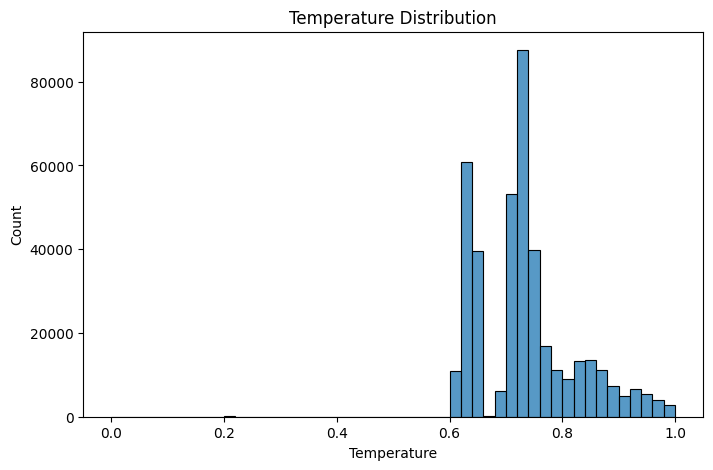

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot temperature distribution
plt.figure(figsize=(8,5))
sns.histplot(df['temp'], bins=50)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()

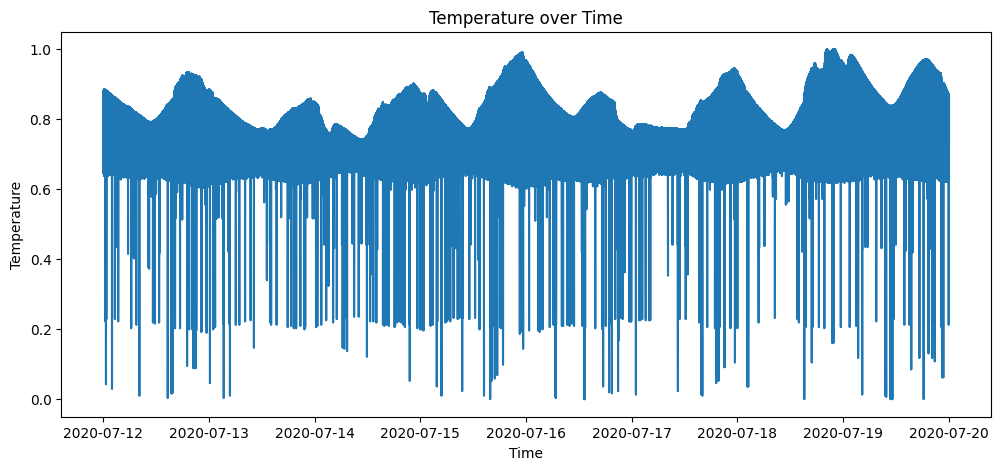

In [16]:
# Plot temperature over time
plt.figure(figsize=(12,5))
plt.plot(df['ts'], df['temp'])
plt.title("Temperature over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

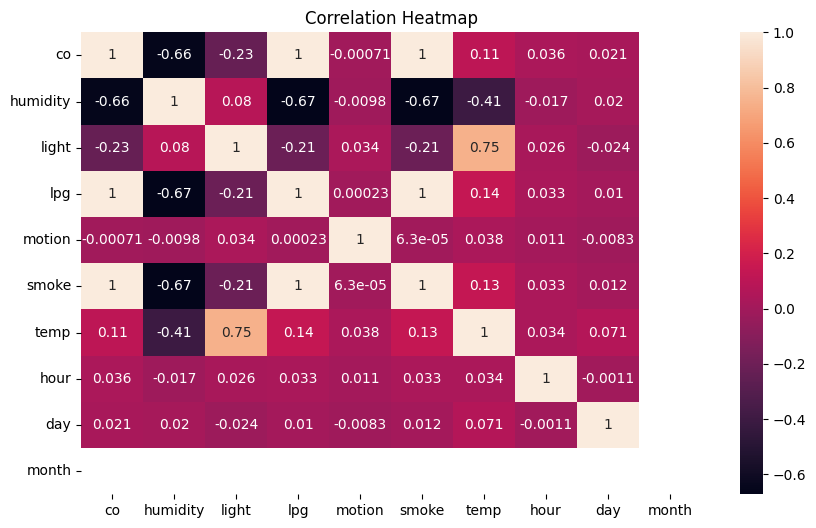

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Define features and target
X = df[['co', 'humidity', 'light', 'lpg', 'motion', 'smoke', 'hour', 'day']]
y = df['temp']

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (405171, 8)
y shape: (405171,)


,co,humidity,light,lpg,motion,smoke,hour,day
0,0.285702,0.505061,0,0.357314,0,0.343856,0,12
1,0.126010,0.758097,0,0.174493,0,0.164989,0,12
2,0.287217,0.504049,0,0.358929,0,0.345456,0,12
3,0.243971,0.766194,1,0.312087,0,0.299166,0,12
4,0.286564,0.504049,0,0.358234,0,0.344767,0,12


In [19]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check split sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (324136, 8)
X_test shape: (81035, 8)
y_train shape: (324136,)
y_test shape: (81035,)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluate Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 0.02380887254929523
MSE: 0.001549630079842882
RMSE: 0.03936534109902875
R2 Score: 0.7997368043629869


In [21]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 0.0028765994823400395
MSE: 0.00020321546802095833
RMSE: 0.014255366288558086
R2 Score: 0.9737378748914872


In [22]:
# Predict on training and testing data
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

# Calculate R2 for train and test
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9860042214212132
Test R2: 0.9737378748914872


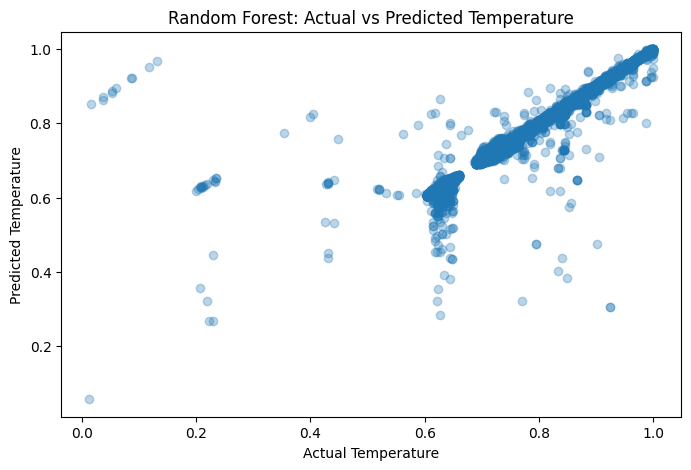

In [23]:
# Plot actual vs predicted values for Random Forest
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Random Forest: Actual vs Predicted Temperature")
plt.show()

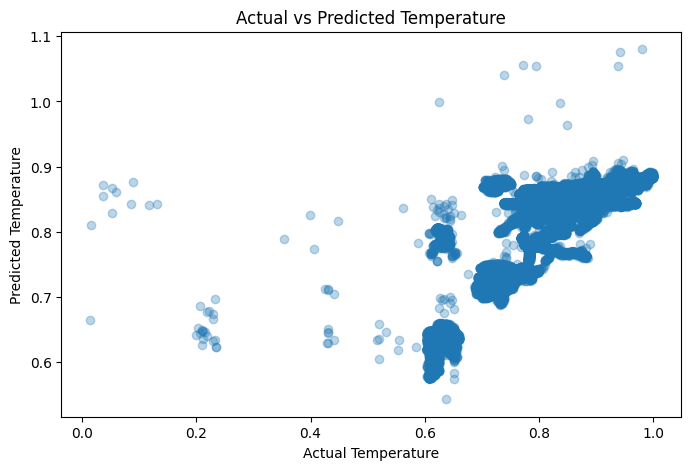

In [25]:
# Plot actual vs predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

In [26]:
# Compare model performance
print("Model Comparison")
print("Linear Regression R2:", r2_lr)
print("Random Forest R2:", r2_rf)

Model Comparison
Linear Regression R2: 0.7997368043629869
Random Forest R2: 0.9737378748914872


In [33]:
pred_df = X_test.copy()
pred_df["Actual_Temp"] = y_test.values
pred_df["Predicted_LR"] = y_pred_lr
pred_df["Predicted_RF"] = y_pred_rf
pred_df.to_csv("predictions.csv", index=False)
print("Saved: predictions.csv")

Saved: predictions.csv


In [34]:
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})
metrics_df.to_csv("metrics.csv", index=False)
print("Saved: metrics.csv")

Saved: metrics.csv


In [35]:
sample_df = clean_df.iloc[:5000]
sample_df.to_csv("clean_iot_data.csv", index=False)

In [36]:
from google.colab import files

files.download("clean_iot_data.csv")
files.download("predictions.csv")
files.download("metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>